## Notes

- Minimum 2 hectares parcels are ok, if near bigger parcels. They might consider using them anyway.
- For Dhar, up to 50m inter-khasra distance is okay.

In [1]:
INDIA_PROJECTED_CRS = "24378"

## Setup

In [2]:
# set libraries to refresh
%load_ext autoreload
%autoreload 2

In [3]:
from pathlib import Path
import networkx as nx
import numpy as np
import pandas as pd
import geopandas as gpd


from joblib import Parallel, delayed

# import kml reading and set supported driver
import fiona

fiona.drvsupport.supported_drivers["KML"] = "rw"

In [4]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import math
import matplotlib.cm

def generate_colormap(N):
    arr = np.arange(N)/N
    N_up = int(math.ceil(N/7)*7)
    arr.resize(N_up)
    arr = arr.reshape(7,N_up//7).T.reshape(-1)
    ret = matplotlib.cm.hsv(arr)
    n = ret[:,3].size
    a = n//2
    b = n-a
    for i in range(3):
        ret[0:n//2,i] *= np.arange(0.2,1,0.8/a)
    ret[n//2:,3] *= np.arange(1,0.3,-0.7/b)
    return ret

In [5]:
from gridsample.utils import create_ids, save_shapefiles
# from gridsample.mapping.plot import create_interactive_map

In [6]:
ROOT_DIR = Path("../")
DATA_DIR = ROOT_DIR / "data"
RAW_DATA_DIR = DATA_DIR / "00_raw"
CLEANED_DATA_DIR = DATA_DIR / "01_processed" / "Solar Parks" / "01 Cleaned Khasras"
OUTPUT_DATA_DIR = DATA_DIR / "01_processed" / "Solar Parks" / "03 Suggested Parcels" / "v2"

## Load cleaned khasras

In [7]:
# Dhar
# dhar_gdf = gpd.read_parquet(CLEANED_DATA_DIR / "dhar_cleaned_khasras.parquet")

In [8]:
# Sagar
sagar_gdf = gpd.read_parquet(CLEANED_DATA_DIR / "sagar_cleaned_khasras.parquet")
# filter to only the "PA" PAR_TYPE (since it looks like the barren land)
sagar_gdf = sagar_gdf[sagar_gdf["PAR_TYPE"] == "PA"]

# 1. Cluster khasras into parcels

### Functions

In [9]:
def build_graph_from_gdf_with_distance_threshold(
    gdf,
    distance_threshold=1000,
    n_jobs=-1,
):
    """
    Build a graph from a GeoDataFrame where the nodes are the index of the GeoDataFrame
    and the edges are the distance between the geometries.

    Parameters
    ----------
    gdf : GeoDataFrame
        The GeoDataFrame to build the graph from. Must be in a projected coordinate system.
    distance_threshold : float
        The maximum distance (meters) to build edges between geometries.
    n_jobs : int
        The number of jobs to run in parallel. -1 means using all processors.

    Returns
    -------
    nx.Graph
        The graph with the distances as the edge attribute.
    """

    if gdf.crs == "EPSG:4326":
        raise ValueError("The GeoDataFrame must be in a projected coordinate system.")

    gdf_temp = gdf.copy()
    gdf_temp["row_number"] = np.arange(len(gdf_temp))

    # determine which edges should be added
    def build_edges_to_nearby_geometries(i, geom1, gdf, distance_threshold):
        buffered_geom = geom1.buffer(distance_threshold)
        gdf_intersecting_subset = gdf[gdf.intersects(buffered_geom)]
        edges = []
        for j, geom2 in zip(
            gdf_intersecting_subset["row_number"], gdf_intersecting_subset["geometry"]
        ):
            if i < j:
                distance = geom1.distance(geom2)
                edges.append((gdf_temp.index[i], gdf_temp.index[j], distance))
        return edges

    # apply the function in parallel
    list_of_lists_of_edges = Parallel(n_jobs=n_jobs)(
        delayed(build_edges_to_nearby_geometries)(
            i, geom1, gdf_temp, distance_threshold
        )
        for i, geom1 in zip(gdf_temp["row_number"], gdf_temp["geometry"])
    )

    # flatten the list of lists of edges
    edges = [edge for edges in list_of_lists_of_edges for edge in edges]

    # Build the graph
    G = nx.Graph()
    G.add_nodes_from(gdf_temp.index)
    G.add_weighted_edges_from(edges)

    print(
        f"Graph built with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges."
    )
    return G

In [10]:
def get_connected_components_by_distance_threshold(G, distance_threshold=None, parcel_id_col_name="parcel_id"):
    """
    Get the connected components of a graph by a distance threshold. The connected components are
    the nodes that are within the distance threshold of each other.

    Parameters
    ----------
    G : nx.Graph
        The graph to get the connected components from.
    distance_threshold : float, optional
        The distance threshold to use to get the connected components.

    Returns
    -------
    cluster_labels_df : pd.DataFrame
        A DataFrame that maps each node (index) to its cluster label.
    G_filtered_with_cluster_labels : nx.Graph
        The graph with edges filtered by the distance threshold with the cluster labels as node attributes.
    """

    def filter_edges_by_weight(G, max_weight):
        """Helper function - Filter a graph by a maximum weight threshold."""

        # this looping method might be slow. Fix later if need be.
        G_filtered = G.copy()
        for edge in G.edges(data=True):
            if edge[2]["weight"] > max_weight:
                G_filtered.remove_edge(edge[0], edge[1])
        return G_filtered

    # filter to only the edges that are within the distance threshold and get the connected components
    if distance_threshold:
        G_filtered = filter_edges_by_weight(G, max_weight=distance_threshold)
    else:
        G_filtered = G

    # print(len(G.edges), "edges filtered to", len(G_filtered.edges), "by distance threshold", distance_threshold)
    list_of_sets_of_connected_nodes = list(nx.connected_components(G_filtered))

    # create parcel ids
    parcel_ids = create_ids(len(list_of_sets_of_connected_nodes), prefix="PARCEL_")

    # create a dictionary that maps each node to its parcel_id.
    node_to_parcel_id = {}
    for parcel_id, connected_nodes in zip(parcel_ids, list_of_sets_of_connected_nodes):
        for node in connected_nodes:
            node_to_parcel_id[node] = parcel_id

    # create a dataframe that maps each node (as index) to its parcel_id
    cluster_labels_df = pd.DataFrame(
        {parcel_id_col_name: node_to_parcel_id.values()},
        index=list(node_to_parcel_id.keys()),
    )

    # add the parcel_id attribute to the nodes
    G_filtered_with_parcel_id = G_filtered.copy()
    for node in G_filtered_with_parcel_id.nodes:
        G_filtered_with_parcel_id.nodes[node][parcel_id_col_name] = node_to_parcel_id[node]

    return cluster_labels_df, G_filtered_with_parcel_id

### Apply

In [11]:
# LOCATION = "Dhar"
# gdf = dhar_gdf.to_crs(INDIA_PROJECTED_CRS).reset_index(drop=True)[
#     [
#         "geometry",
#         "khasra_id",
#         "village_name",
#     ]
# ]

In [12]:
LOCATION = "Sagar"
gdf = sagar_gdf.to_crs(INDIA_PROJECTED_CRS).reset_index(drop=True)[
    [
        "geometry",
        "UNQID",
        "village_name",
    ]
]
gdf.rename(columns={"UNQID": "khasra_id"}, inplace=True)

In [13]:
gdf["Khasra Area (ha)"] = gdf.area / 10_000

<Axes: >

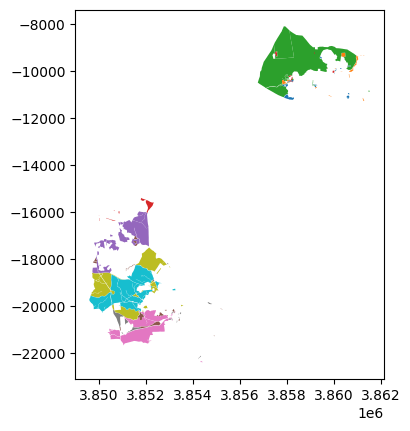

In [14]:
gdf.plot(column="khasra_id")

In [15]:
# get graph, only considering neighbours within 1000 meters
G = build_graph_from_gdf_with_distance_threshold(gdf, distance_threshold=200)

Graph built with 209 nodes and 1006 edges.


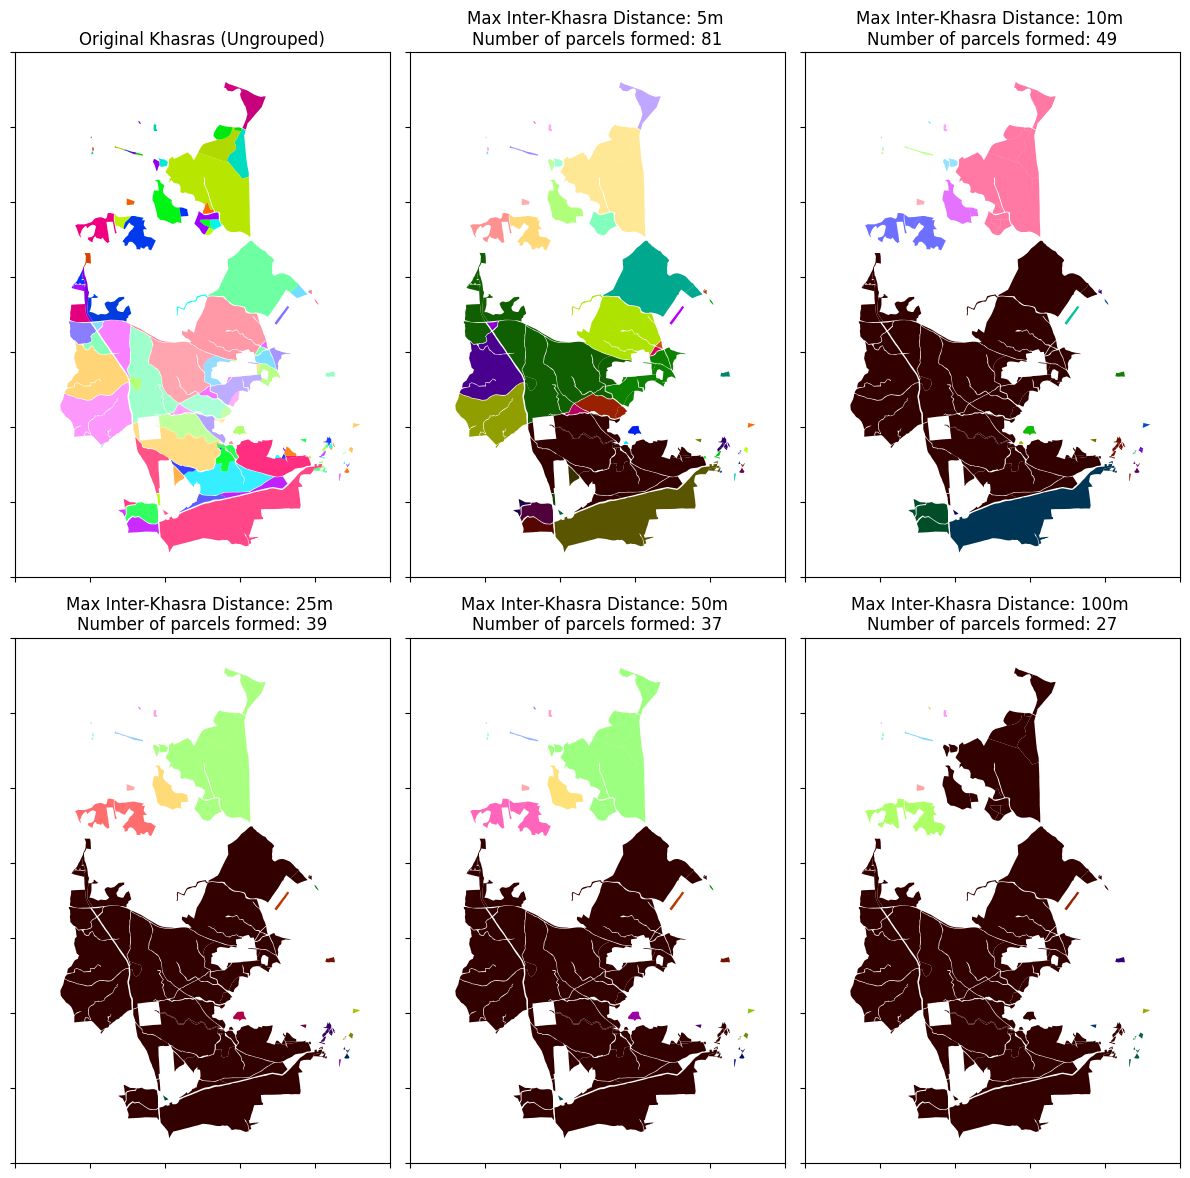

In [ ]:
f, ax = plt.subplots(2, 3, figsize=(12, 12))
ax = ax.flatten()

gdf_with_parcel_id = gdf.copy()
G_filtered_dict = {}

# plot original khasras
gdf.plot(ax=ax[0], column="khasra_id", cmap=ListedColormap(generate_colormap(len(gdf))))
ax[0].set_title("Original Khasras (Ungrouped)", fontsize=12)
ax[0].set_xticklabels([])
ax[0].set_yticklabels([])

xmin, xmax = 3_849_000, 3_854_000
ymin, ymax = -22000, -15000
ax[0].set_xlim(xmin, xmax)
ax[0].set_ylim(ymin, ymax)

for i, distance_threshold in enumerate([5, 10, 25, 50, 100]):

    temp_parcel_id_col = f"parcel_id_{distance_threshold}m"

    cluster_labels_df, G_filtered_with_parcel_id = (
        get_connected_components_by_distance_threshold(G, distance_threshold)
    )
    G_filtered_dict[distance_threshold] = G_filtered_with_parcel_id
    cluster_labels_df.rename(columns={"parcel_id": temp_parcel_id_col}, inplace=True)
    # add parcel_id to gdf
    gdf_with_parcel_id = gdf_with_parcel_id.merge(
        cluster_labels_df, left_index=True, right_index=True, how="left"
    )

    N = len(gdf_with_parcel_id[temp_parcel_id_col].unique())

    i = i + 1 # start from second plot position
    gdf_with_parcel_id.plot(column=temp_parcel_id_col, ax=ax[i], cmap=ListedColormap(generate_colormap(N)))
    ax[i].set_title(
        f"Max Inter-Khasra Distance: {distance_threshold}m \nNumber of parcels formed: {N}",
        fontsize=12,
    )
    ax[i].set_xticklabels([])
    ax[i].set_yticklabels([])
    # set diplay limits
    ax[i].set_xlim(xmin, xmax)
    ax[i].set_ylim(ymin, ymax)

plt.tight_layout()
plt.savefig(OUTPUT_DATA_DIR / LOCATION / "parcels_w_different_thresholds_cropped.png", dpi=300)

#### Do it for the decided threshold

In [34]:
distance_threshold = 25

In [39]:
cluster_labels_df, G_filtered_with_parcel_id = (
    get_connected_components_by_distance_threshold(G, distance_threshold)
)
G_filtered_dict[distance_threshold] = G_filtered_with_parcel_id

In [40]:
# add parcel_id to gdf
gdf_with_parcel_id = gdf.merge(
    cluster_labels_df, left_index=True, right_index=True, how="left"
)

In [42]:
gdf_with_parcel_id

,geometry,khasra_id,village_name,Khasra Area (ha),parcel_id
0,"POLYGON ((3851676.927 -20485.734, 3851674.134 ...",17680194,khamkuwa,29.794942,PARCEL_01
1,"POLYGON ((3851133.441 -20778.459, 3851141.972 ...",17680261,khamkuwa,1.942839,PARCEL_01
2,"POLYGON ((3851414.098 -20557.276, 3851402.185 ...",17680195,khamkuwa,2.007971,PARCEL_01
3,"POLYGON ((3850934.002 -20954.410, 3850929.284 ...",17679771,khamkuwa,0.465409,PARCEL_01
4,"POLYGON ((3854342.517 -22342.587, 3854336.423 ...",17680109,khamkuwa,0.242128,PARCEL_02
...,...,...,...,...,...
204,"POLYGON ((3849946.329 -18474.763, 3849946.700 ...",17679500,tekapar,2.640908,PARCEL_01
205,"POLYGON ((3850273.983 -18330.190, 3850259.565 ...",17679498,tekapar,9.574600,PARCEL_01
206,"POLYGON ((3851856.971 -16474.327, 3851852.408 ...",17679527,tekapar,69.059040,PARCEL_34
207,"POLYGON ((3850896.198 -16047.395, 3850897.526 ...",17679301,tekapar,0.324277,PARCEL_38


In [46]:
# manually combine PARCEL_01 and PARCEL_34
gdf_with_parcel_id.loc[gdf_with_parcel_id["parcel_id"] == "PARCEL_34", "parcel_id"] = "PARCEL_01"

<Axes: >

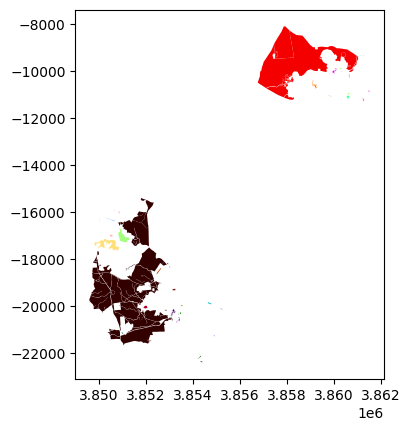

In [47]:
gdf_with_parcel_id.plot(
    column="parcel_id",
    cmap=ListedColormap(
        generate_colormap(len(gdf_with_parcel_id["parcel_id"].unique()))
    ),
)

<Axes: >

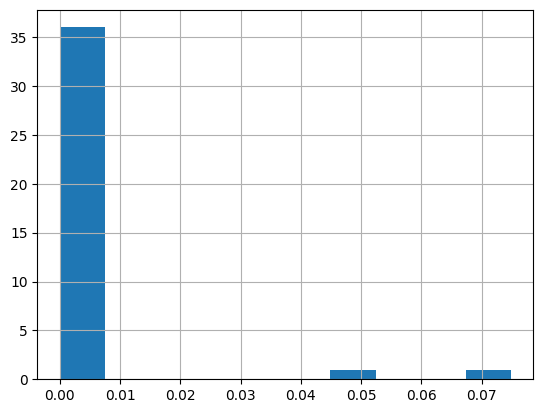

In [48]:
# get size histogram per parcel id col
(gdf_with_parcel_id.groupby("parcel_id")["Khasra Area (ha)"].sum().sort_values(ascending=False)/10_000).hist()

In [49]:
save_shapefiles(
    gdf_with_parcel_id.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / LOCATION,
    "khasras_with_parcel_id_initial",
    formats=["parquet", "kml", "csv"],
)

### Make parcel-level gdf

#### Functions

In [50]:
def get_closest_parcels(gdf, parcel_id_col="parcel_id"):
    min_distances = []
    closest_ids = []
    for i in range(len(gdf)):
        geom = gdf.iloc[i].geometry
        other_geoms = gdf.drop(gdf.index[i])
        distances = other_geoms.geometry.apply(lambda x: geom.distance(x))
        min_distance = distances.min().round(2)
        closest_id = other_geoms.loc[distances.idxmin()][parcel_id_col]
        min_distances.append(min_distance)
        closest_ids.append(closest_id)
    return min_distances, closest_ids

In [51]:
def get_intra_parcel_distance_stats(G_filtered, parcel_ids, parcel_id_col="parcel_id"):
    """
    Get the inter-khasra distance stats within each parcel.

    Parameters
    ----------
    G_filtered : nx.Graph
        The graph with the edges filtered by the distance threshold.
    parcel_ids : list
        The list of parcel_ids to get the distances for.

    Returns
    -------
    pd.DataFrame
        A DataFrame with the parcel_id and corresponding distance stats.
    """

    # helper function to get the edge weights of a parcel_id
    def get_edge_weights_by_parcel_id(G_filtered, parcel_id):
        selected_nodes = {
            n for n, d in G_filtered.nodes(data=True) if d.get(parcel_id_col) == parcel_id
        }
        subgraph = G_filtered.subgraph(selected_nodes)
        edge_weights = [d["weight"] for _, _, d in subgraph.edges(data=True)]
        return edge_weights

    distances_list = []
    for parcel_id in parcel_ids:
        distances = get_edge_weights_by_parcel_id(G_filtered, parcel_id)
        if len(distances) == 0:
            avg_distance = 0
            min_distance = 0
            percentile_25th_distance = 0
            percentile_50th_distance = 0
            percentile_75th_distace = 0
            max_distance = 0
        else:
            # avg
            avg_distance = np.mean(distances)
            # min 25% quartile, median, 75% quantile, max
            min_distance = np.min(distances)
            percentile_25th_distance = np.percentile(distances, 20)
            percentile_50th_distance = np.percentile(distances, 50)
            percentile_75th_distace = np.percentile(distances, 75)
            max_distance = np.max(distances)

        distances_list.append({
            parcel_id_col: parcel_id,
            "Inter-Khasra Distance Average (m)": avg_distance,
            "Inter-Khasra Distance Min (m)": min_distance,
            "Inter-Khasra Distance 25th Percentile (m)": percentile_25th_distance,
            "Inter-Khasra Distance Median (m)": percentile_50th_distance,
            "Inter-Khasra Distance 75th Percentile (m)": percentile_75th_distace,
            "Inter-Khasra Distance Max (m)": max_distance,
            "raw_distances": distances,
        })
    
    return pd.DataFrame(distances_list).round(2)

#### Code

In [52]:
# Group by the cluster value and dissolve to make a new GeoDataFrame. Remove the DISCARDED khasras before this.
parcel_gdf = gdf_with_parcel_id.dissolve(by="parcel_id")
parcel_gdf = parcel_gdf.drop(columns=["khasra_id", "Khasra Area (ha)"])
parcel_gdf = parcel_gdf.reset_index()

In [53]:
parcel_gdf.loc[:, "Original Parcel Area (ha)"] = parcel_gdf["geometry"].area / 10_000

In [55]:
# filter to only parcels larger than X
min_parcel_area_ha = 50
filtered_parcel_gdf = parcel_gdf[parcel_gdf["Original Parcel Area (ha)"] > min_parcel_area_ha]

# relabel them to DISCARDED in the khasra gdf too
too_small_parcel_ids = parcel_gdf[parcel_gdf["Original Parcel Area (ha)"] < min_parcel_area_ha][
    "parcel_id"
].values
filtered_gdf_with_parcel_id = gdf_with_parcel_id.copy()
filtered_gdf_with_parcel_id.loc[
    filtered_gdf_with_parcel_id["parcel_id"].isin(too_small_parcel_ids), "parcel_id"
] = "DISCARDED"

In [56]:
# list(filtered_gdf_with_parcel_id[filtered_gdf_with_parcel_id["parcel_id"] == "DISCARDED"]["khasra_id"])

In [57]:
# add how many khasras are inside
khasra_counts_series = gdf_with_parcel_id.groupby("parcel_id")["khasra_id"].count()
filtered_parcel_gdf["Khasra Count"] = filtered_parcel_gdf["parcel_id"].map(khasra_counts_series)

# add the names of all khasras that fall inside each parcel as a list under khasra_ids
khasra_ids_series = gdf_with_parcel_id.groupby("parcel_id")["khasra_id"].apply(list).astype(str)
filtered_parcel_gdf["Khasra IDs"] = filtered_parcel_gdf["parcel_id"].map(khasra_ids_series)

/Users/amiremami/miniconda3/envs/clustering/lib/python3.11/site-packages/geopandas/geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/Users/amiremami/miniconda3/envs/clustering/lib/python3.11/site-packages/geopandas/geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [58]:
# Calculate minimum distances and closest parcel_ids
min_distances, closest_ids = get_closest_parcels(filtered_parcel_gdf, parcel_id_col="parcel_id")

# Add the results as new columns
filtered_parcel_gdf.loc[:, "Closest Parcel Distance (m)"] = min_distances
filtered_parcel_gdf.loc[:, "Closest Parcel ID"] = closest_ids

/Users/amiremami/miniconda3/envs/clustering/lib/python3.11/site-packages/geopandas/geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/Users/amiremami/miniconda3/envs/clustering/lib/python3.11/site-packages/geopandas/geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [59]:
intra_distances_df = get_intra_parcel_distance_stats(
    G_filtered_with_parcel_id,
    filtered_parcel_gdf["parcel_id"].unique(),
    parcel_id_col="parcel_id",
)

In [61]:
filtered_parcel_gdf = filtered_parcel_gdf.join(
    intra_distances_df.set_index("parcel_id").drop(columns="raw_distances"),
    on="parcel_id",
)

In [62]:
filtered_parcel_gdf = filtered_parcel_gdf.sort_values(by="Original Parcel Area (ha)", ascending=False)

In [64]:
# drop if far and small...

## Save parcel files

In [65]:
save_shapefiles(
    filtered_parcel_gdf.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / LOCATION,
    "parcels_filtered",
    formats=["parquet", "kml", "csv"],
)

# 2. Add unusable layers

## Water

In [66]:
water_bodies_gdf = gpd.read_file(RAW_DATA_DIR / "water" / "DWA Waterbodies Ph1 for Madhya Pradesh.geojson")
water_bodies_gdf = water_bodies_gdf.to_crs(INDIA_PROJECTED_CRS)

# get cutout of the water shapes that overlap parcels
water_overlap_gdf = gpd.overlay(
    water_bodies_gdf, filtered_parcel_gdf, how="intersection"
)
water_overlap_gdf = water_overlap_gdf.dissolve(by="parcel_id").reset_index()

In [67]:
water_overlap_gdf["Unusable Area Water (ha)"] = water_overlap_gdf.area / 10_000
water_unusable_area_df = water_overlap_gdf[["parcel_id", "Unusable Area Water (ha)"]]

In [68]:
# ax = filtered_parcel_gdf.plot(figsize=(10, 10), color="brown")
# water_overlap_gdf.plot(ax=ax)

### Buildings

In [69]:
from s2cell.s2cell import lat_lon_to_cell_id
import boto3

#### Download rooftop data

Get the ID of the level 6 S2 Cell that this area sits inside

In [70]:
s2_ids = []

for index, row in filtered_parcel_gdf.to_crs(4326).iterrows():
    lat = row["geometry"].centroid.y
    lon = row["geometry"].centroid.x
    s2_cell_id = lat_lon_to_cell_id(lat=lat, lon=lon, level=6)
        
    s2_ids.append(s2_cell_id)

s2_ids = list(set(s2_ids))


Download closest S2 cell shapefile from https://beta.source.coop/vida/google-microsoft-open-buildings/geoparquet/by_country_s2/country_iso=IND/

In [71]:
for s2_cell_id in s2_ids:
    s2_rooftops_path = RAW_DATA_DIR / "rooftops" / f"{s2_cell_id}.parquet"

    if s2_rooftops_path.exists():
        print("File already exists")
    else:
        s3 = boto3.client("s3", endpoint_url="https://data.source.coop")
        s3.download_file(
            "vida",
            f"google-microsoft-open-buildings/geoparquet/by_country_s2/country_iso=IND/{s2_cell_id}.parquet",
            str(s2_rooftops_path),
        )
        print("File downloaded.")

File already exists


#### Load and process rooftop data

In [72]:
rooftop_gdf_list = []
for s2_cell_id in s2_ids:
    s2_rooftops_path = RAW_DATA_DIR / "rooftops" / f"{s2_cell_id}.parquet"
    rooftop_gdf = gpd.read_parquet(s2_rooftops_path)
    rooftop_gdf_list.append(rooftop_gdf)

rooftop_gdf = pd.concat(rooftop_gdf_list, ignore_index=True)
rooftop_gdf = rooftop_gdf[
    [
        "bf_source",
        "confidence",
        "area_in_meters",
        "geometry",
    ]
]

rooftop_gdf["rooftop_id"] = create_ids(len(rooftop_gdf), f"ROOFTOP_S2_{s2_cell_id}_")
rooftop_gdf = rooftop_gdf.to_crs(INDIA_PROJECTED_CRS)

In [73]:
subset_rooftops_gdf = rooftop_gdf.sjoin(
    filtered_parcel_gdf, how="inner", predicate="intersects"
).drop(columns=["index_right"])
subset_rooftops_gdf.drop(
    columns=filtered_parcel_gdf.columns.drop("geometry"), inplace=True
)

In [74]:
buffer = 25
buffered_rooftops_gdf = subset_rooftops_gdf.copy()
buffered_rooftops_gdf["geometry"] = buffered_rooftops_gdf.buffer(buffer)

# get cutout of the buffered building shapes that overlap parcels
buildings_overlap_gdf = gpd.overlay(
    buffered_rooftops_gdf, filtered_parcel_gdf, how="intersection"
)
# merge them so we don't double-count building overlaps
buildings_overlap_gdf = buildings_overlap_gdf.dissolve(by="parcel_id").reset_index()

In [75]:
buildings_overlap_gdf["Unusable Area Buildings (ha)"] = buildings_overlap_gdf.area / 10_000
building_unusable_area_df = buildings_overlap_gdf[["parcel_id", "Unusable Area Buildings (ha)"]]

In [76]:
# ax = filtered_parcel_gdf.plot(figsize=(10, 10), color="brown")
# water_overlap_gdf.plot(ax=ax)
# buildings_overlap_gdf.plot(ax=ax, color="yellow")

## Landcover (Cropland, Water later)

### Landcover

In [77]:
# for TIFF files
import rasterio
from rasterio.plot import show
from rasterstats import zonal_stats
from rasterio.features import shapes
from shapely.geometry import shape

In [78]:
def get_landcover_shapes(
    landcover_data,
    transform,
    class_name,
    class_value_lookup_dict,
    raster_crs="4326",
    target_crs="24378",
):
    # Get array values
    class_name = "Cropland"
    class_values = class_value_lookup_dict[class_name]

    # Create mask
    layer_mask = np.isin(landcover_data, class_values)

    # Extract vector shapes and make a GeoDataFrame
    vector_shapes = [
        {"geometry": shape(geom), "properties": {"class": class_name}}
        for geom, class_value in shapes(
            landcover_data, mask=layer_mask, transform=transform
        )
    ]
    shapes_gdf = gpd.GeoDataFrame(vector_shapes, crs=raster_crs)
    shapes_gdf = shapes_gdf.to_crs(target_crs)

    return shapes_gdf

In [79]:
path = "../data/00_raw/landcover/30N_070E_2020.tif"
src = rasterio.open(path)

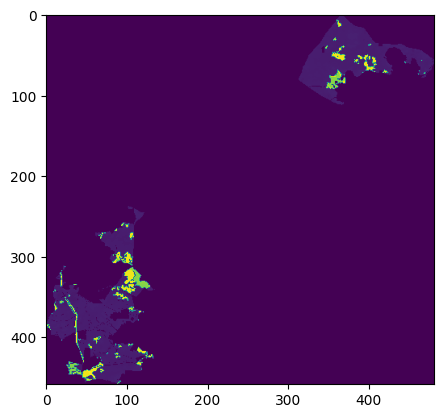

<Axes: >

In [80]:
masked_landcover_data, masked_transform = rasterio.mask.mask(src, [filtered_parcel_gdf.to_crs(4326).unary_union], crop=True)
masked_landcover_data = np.squeeze(masked_landcover_data)
show(masked_landcover_data)

In [81]:
# load value to landcover type mapping legend
legend_df = pd.read_csv(RAW_DATA_DIR / "landcover" / "legend_processed.csv")
landcover_value_class_dict = legend_df.set_index("map_value")["class_b"].to_dict()

landcover_class_value_dict = {}
for key, value in landcover_value_class_dict.items():
    if value not in landcover_class_value_dict:
        landcover_class_value_dict[value] = [key]
    else:
        landcover_class_value_dict[value].append(key)
landcover_class_value_dict

{'True desert': [0, 1],
 'Semi-arid': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18],
 'Dense short vegetation': [19,
  20,
  21,
  22,
  23,
  24,
  119,
  120,
  121,
  122,
  123,
  124],
 'Tree cover': [25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  125,
  126,
  127,
  128,
  129,
  130,
  131,
  132,
  133,
  134,
  135,
  136,
  137,
  138,
  139,
  140,
  141,
  142,
  143,
  144,
  145,
  146,
  147,
  148],
 'Salt pan': [100, 101],
 'Sparse vegetation': [102,
  103,
  104,
  105,
  106,
  107,
  108,
  109,
  110,
  111,
  112,
  113,
  114,
  115,
  116,
  117,
  118],
 'Open surface water': [200, 201, 202, 203, 204, 205, 206, 207],
 'Snow/ice': [241],
 'Cropland': [244],
 'Built-up': [250],
 'Ocean': [254],
 'No Data': [255]}

In [82]:
cropland_shapes_gdf = get_landcover_shapes(
    masked_landcover_data,
    masked_transform,
    class_name="Cropland",
    class_value_lookup_dict=landcover_class_value_dict,
    raster_crs=src.crs,
    target_crs=INDIA_PROJECTED_CRS,
)

In [83]:
# get cutout of the water shapes that overlap parcels
cropland_overlap_gdf = gpd.overlay(
    cropland_shapes_gdf, filtered_parcel_gdf, how="intersection"
)
cropland_overlap_gdf = cropland_overlap_gdf.dissolve(by="parcel_id").reset_index()

In [84]:
cropland_overlap_gdf["Unusable Area Cropland (ha)"] = cropland_overlap_gdf.area / 10_000
cropland_unusable_area_df = cropland_overlap_gdf[["parcel_id", "Unusable Area Cropland (ha)"]]

#### Extra landcover stats

In [85]:
landcover_stats = zonal_stats(
    filtered_parcel_gdf.to_crs(4326),
    masked_landcover_data,
    affine=masked_transform,
    categorical=True,
    all_touched=True,
    category_map=landcover_value_class_dict,
)
# make list of dics into df with keys as columns and values as rows
landcover_df = pd.DataFrame(landcover_stats, index=filtered_parcel_gdf.index)
landcover_df = landcover_df.fillna(0)

# add total count column
landcover_df["total_count"] = landcover_df.sum(axis=1)
# divide by total count to get percentage
landcover_df_perc = (
    (landcover_df.div(landcover_df["total_count"], axis=0) * 100)
    .round(1)
    .drop(columns="total_count")
)
# add % to column names
landcover_df_perc.columns = [f"{col} %" for col in landcover_df_perc.columns]
landcover_df["parcel_id"] = filtered_parcel_gdf["parcel_id"]
landcover_df_perc["parcel_id"] = filtered_parcel_gdf["parcel_id"]

/Users/amiremami/miniconda3/envs/clustering/lib/python3.11/site-packages/rasterstats/io.py:335: NodataWarning: Setting nodata to -999; specify nodata explicitly
  warnings.warn(


## Slope

In [87]:
import shapely
from rasterio import Affine
from rasterio.enums import Resampling

Source: https://bhuvan-app3.nrsc.gov.in/data/download/index.php

ISRO CartoDEM Version-3 R1, 30m resolution. The Cartosat-1 Digital Elevation Model (CartoDEM) is a National DEM developed by the Indian Space Research Organization (ISRO). It is derived from the Cartosat-1 stereo payload launched in May 2005. PDFs in folder.


#### Load slope data

In [88]:
# for upscaling raster so that more points fall within shapes
def upscale_raster(src, scale, original_cellsize_m):

    transform = src.transform

    # rescale the metadata
    upscaled_transform = Affine(
        transform.a * scale,
        transform.b,
        transform.c,
        transform.d,
        transform.e * scale,
        transform.f,
    )
    height = int(src.height / scale)
    width = int(src.width / scale)

    # read the data
    upscaled_src = src.read(
        1,
        masked=True,
        out_shape=(height, width),
        resampling=Resampling.bilinear,
    )

    # calculate the new cellsize
    upscaled_cellsize_m = int(original_cellsize_m * scale)

    return upscaled_src, upscaled_transform, upscaled_cellsize_m

In [89]:
def get_slope_array(dem_array, cellsize=30):
    px, py = np.gradient(dem_array, cellsize)
    slope = np.sqrt(px ** 2 + py ** 2)
    return np.degrees(np.arctan(slope))

Processing DEM: cdnf44a


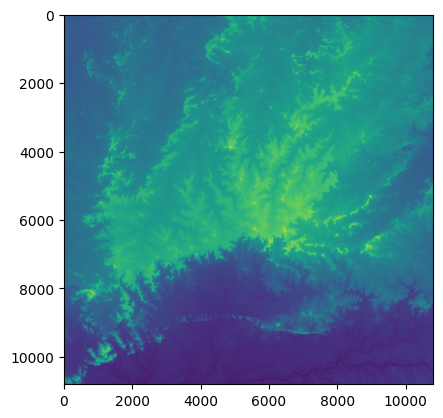

<Axes: >

In [90]:
dem_filenames = ["cdnf44a"]
original_cellsize_m = 30
scale = (1 / 3)

# for dem_filename in dem_filenames:
dem_filename = dem_filenames[0]

print("Processing DEM:", dem_filename)
path = RAW_DATA_DIR / "elevation" / f"{dem_filename}.tif"
dem_dataset = rasterio.open(path)
# dem = dem_dataset.read(1)
# affine = dem_dataset.transform

# upscale the raster by 6 times (means we can get stats for smaller shapes)
upscaled_dem, upscaled_transform, upscaled_cellsize_m = upscale_raster(
    dem_dataset, scale=scale, original_cellsize_m=original_cellsize_m
)

show(upscaled_dem)

In [91]:
# get bounding box of dem
dem_bounds = dem_dataset.bounds
dem_shape = shapely.geometry.box(*dem_bounds)

# mask gdf to rows that intersect this bounding box
gdf_dem_mask = filtered_parcel_gdf.intersects(dem_shape)

# calculate slopes
slope_array = get_slope_array(upscaled_dem, cellsize=upscaled_cellsize_m)

dem_dataset.close()

In [92]:
# Extract vector shapes and make a GeoDataFrame
vector_shapes = [
    {"geometry": shape(geom), "properties": {"class": "higher_than_30"}}
    for geom, class_value in shapes(
        slope_array, mask=slope_array > 7, transform=upscaled_transform
    )
]
slope_shapes_gdf = gpd.GeoDataFrame(vector_shapes)
slope_shapes_gdf = slope_shapes_gdf.set_crs(4326).to_crs(INDIA_PROJECTED_CRS)

In [93]:
slope_overlap_gdf = gpd.overlay(
    slope_shapes_gdf, filtered_parcel_gdf, how="intersection", keep_geom_type=False
)
slope_overlap_gdf = slope_overlap_gdf.dissolve(by="parcel_id").reset_index()

<Axes: >

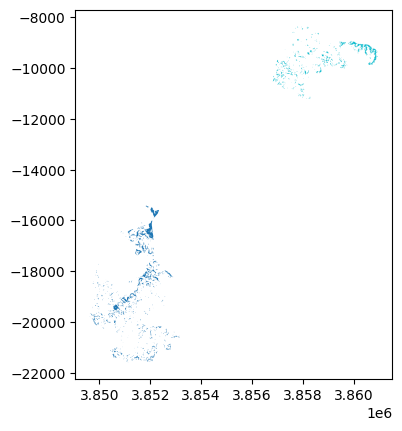

In [94]:
slope_overlap_gdf.plot(column="parcel_id")

In [95]:
slope_overlap_gdf["Unusable Area Slope (ha)"] = slope_overlap_gdf.area / 10_000
slope_unusable_area_df = slope_overlap_gdf[["parcel_id", "Unusable Area Slope (ha)"]]

In [96]:
# slope_df = pd.read_csv(OUTPUT_DATA_DIR / "Final Export v1" / "10m_slopes_all.csv", index_col=0)
# slope_df = slope_df.iloc[:, 6:]
# slope_df

# Final Calculations

## Plots

In [184]:
CHOSEN_PARCEL_ID = "PARCEL_01" #19
FOLDER_PATH = OUTPUT_DATA_DIR / LOCATION / CHOSEN_PARCEL_ID
FOLDER_PATH.mkdir(parents=True, exist_ok=True)

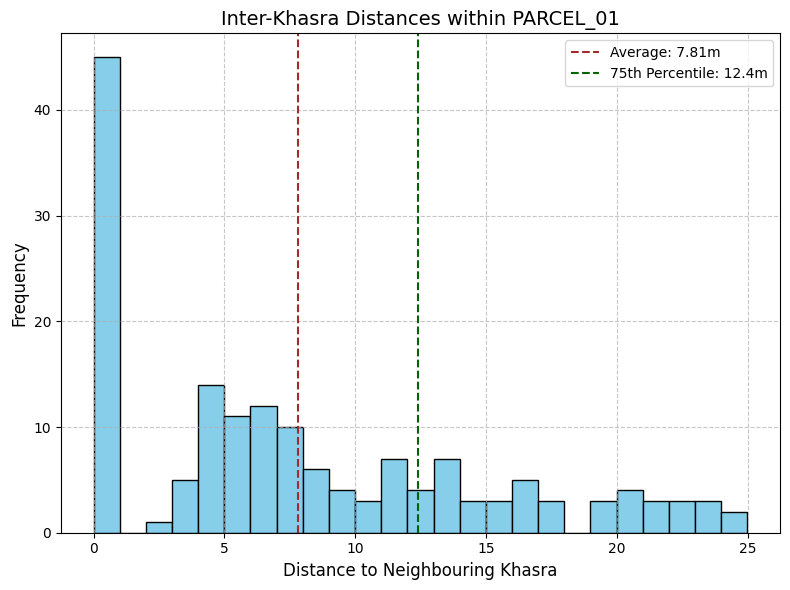

In [185]:
# Plotting the histogram of intra-distances
subset_intra_distances_df = intra_distances_df[
    intra_distances_df["parcel_id"] == CHOSEN_PARCEL_ID
]

f, ax = plt.subplots(1, 1, figsize=(8, 6))
subset_intra_distances_df["raw_distances"].hist(
    ax=ax, bins=25, color="skyblue", edgecolor="black"
)

# add lines for average and 75% percentile
avg_distance = subset_intra_distances_df["Inter-Khasra Distance Average (m)"].values[0]
percentile_75th_distance = subset_intra_distances_df["Inter-Khasra Distance 75th Percentile (m)"].values[0]

ax.axvline(avg_distance, color="brown", linestyle="--", label=f"Average: {avg_distance}m")
ax.axvline(percentile_75th_distance, color="darkgreen", linestyle="--", label=f"75th Percentile: {percentile_75th_distance}m")

ax.legend()
ax.set_title(f"Inter-Khasra Distances within {CHOSEN_PARCEL_ID}", fontsize=14)
ax.set_xlabel("Distance to Neighbouring Khasra", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.savefig(OUTPUT_DATA_DIR / LOCATION / CHOSEN_PARCEL_ID / "intra_distances_histogram.png", dpi=300)
plt.show()

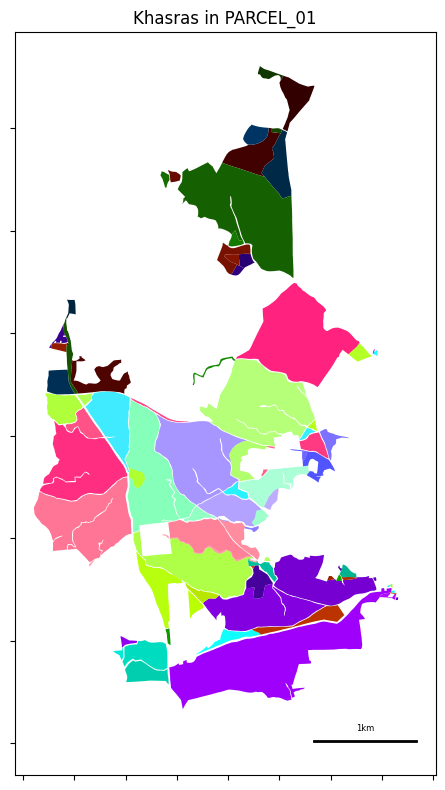

In [186]:
ax = gdf_with_parcel_id[gdf_with_parcel_id["parcel_id"] == CHOSEN_PARCEL_ID].plot(
    column="khasra_id",
    cmap=ListedColormap(
        generate_colormap(len(gdf_with_parcel_id["khasra_id"].unique()))
    ),
    figsize=(8, 8),
)
ax.set_xticklabels([])
ax.set_yticklabels([])

# add a 1km line to show scale on the plot
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
ax.plot([xmax - 1000, xmax], [ymin, ymin], color="white", linewidth=5, linestyle="-")
ax.plot([xmax - 1000, xmax], [ymin, ymin], color="black", linewidth=2, linestyle="-")
ax.plot([xmax - 550, xmax - 450], [ymin + 130, ymin + 130], color="white", linewidth=7, linestyle="-")
ax.text(xmax - 500, ymin + 100, "1km", fontsize=6, ha="center")

ax.set_title(f"Khasras in {CHOSEN_PARCEL_ID}", fontsize=12)

plt.tight_layout()
plt.savefig(OUTPUT_DATA_DIR / LOCATION / CHOSEN_PARCEL_ID / "khasras.png", dpi=300)

In [187]:
import matplotlib.patches as mpatches

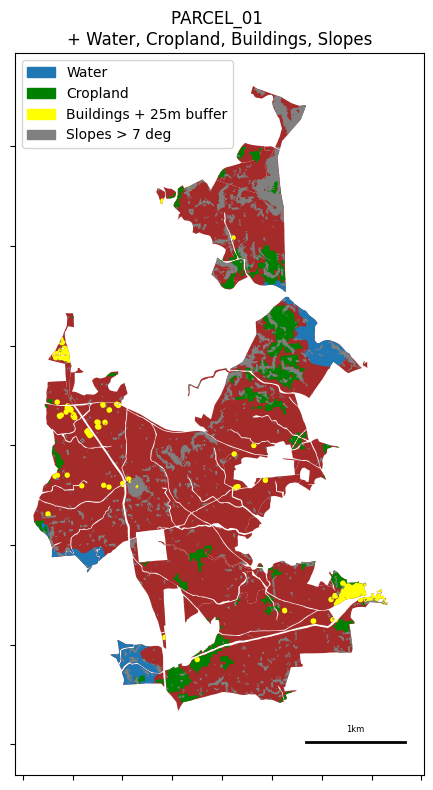

In [192]:
ax = gdf_with_parcel_id[gdf_with_parcel_id["parcel_id"] == CHOSEN_PARCEL_ID].plot(
    color="brown",
    label="Original Parcel",
    figsize=(8, 8),
)
ax.set_title(CHOSEN_PARCEL_ID, fontsize=12)
ax.set_xticklabels([])
ax.set_yticklabels([])

# add a 1km line to show scale on the plot
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
ax.plot([xmax - 1000, xmax], [ymin, ymin], color="white", linewidth=5, linestyle="-")
ax.plot([xmax - 1000, xmax], [ymin, ymin], color="black", linewidth=2, linestyle="-")
ax.plot([xmax - 550, xmax - 450], [ymin + 130, ymin + 130], color="white", linewidth=7, linestyle="-")
ax.text(xmax - 500, ymin + 100, "1km", fontsize=6, ha="center")

handles = []
# unusable layers 
water_overlap_gdf[water_overlap_gdf["parcel_id"] == CHOSEN_PARCEL_ID].plot(ax=ax, color="C0", label="Water")
LAYERS = "Water"
handles.append(mpatches.Patch(color="C0", label="Water"))

cropland_overlap_gdf[cropland_overlap_gdf["parcel_id"] == CHOSEN_PARCEL_ID].plot(ax=ax, color="green", label="Cropland")
LAYERS = "Water, Cropland"
handles.append(mpatches.Patch(color="green", label="Cropland"))

buildings_overlap_gdf[buildings_overlap_gdf["parcel_id"] == CHOSEN_PARCEL_ID].plot(ax=ax, color="yellow", label="Buildings + 25m buffer")
LAYERS = "Water, Cropland, Buildings"
handles.append(mpatches.Patch(color="yellow", label="Buildings + 25m buffer"))

slope_overlap_gdf[slope_overlap_gdf["parcel_id"] == CHOSEN_PARCEL_ID].plot(ax=ax, color="grey", label="Slopes > 7 deg")
LAYERS = "Water, Cropland, Buildings, Slopes"
handles.append(mpatches.Patch(color="grey", label="Slopes > 7 deg"))

ax.legend(handles=handles, loc="upper left")
ax.set_title(f"{CHOSEN_PARCEL_ID} \n+ {LAYERS}", fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DATA_DIR / LOCATION / CHOSEN_PARCEL_ID / f"Layers - {LAYERS}.png", dpi=300)

## Cutout

In [155]:
usable_filtered_parcel_gdf = filtered_parcel_gdf.copy()

# cut out water
usable_filtered_parcel_gdf = gpd.overlay(
    usable_filtered_parcel_gdf, water_overlap_gdf, how="difference", keep_geom_type=False
)

# cut out cropland
usable_filtered_parcel_gdf = gpd.overlay(
    usable_filtered_parcel_gdf, cropland_overlap_gdf, how="difference", keep_geom_type=False
)

# cut out buildings
usable_filtered_parcel_gdf = gpd.overlay(
    usable_filtered_parcel_gdf, buildings_overlap_gdf, how="difference", keep_geom_type=False
)

# cut out slopes
usable_filtered_parcel_gdf = gpd.overlay(
    usable_filtered_parcel_gdf, slope_overlap_gdf, how="difference", keep_geom_type=False
)

GEOSException: TopologyException: found non-noded intersection between LINESTRING (3.84994e+06 -20064.2, 3.84993e+06 -20067.1) and LINESTRING (3.84994e+06 -20056.3, 3.84993e+06 -20067.1) at 3849934.4114406002 -20067.073449715183

In [156]:
usable_filtered_parcel_gdf["Usable Area (ha)"] = usable_filtered_parcel_gdf.area / 10_000
usable_filtered_parcel_gdf["Unsable Area Total (ha)"] = (
    usable_filtered_parcel_gdf["Original Parcel Area (ha)"]
    - usable_filtered_parcel_gdf["Usable Area (ha)"]
)

In [159]:
# add unusable areas
all_unusable_area_cols_df = water_unusable_area_df.merge(building_unusable_area_df, on="parcel_id", how="outer").fillna(0)
all_unusable_area_cols_df = all_unusable_area_cols_df.merge(cropland_unusable_area_df, on="parcel_id", how="outer").fillna(0)
all_unusable_area_cols_df = all_unusable_area_cols_df.merge(slope_unusable_area_df, on="parcel_id", how="outer").fillna(0)

usable_filtered_parcel_gdf = usable_filtered_parcel_gdf.merge(all_unusable_area_cols_df, on="parcel_id", how="left").fillna(0)

In [160]:
usable_filtered_parcel_gdf = usable_filtered_parcel_gdf.merge(landcover_df_perc, on="parcel_id", how="left").fillna(0)

In [163]:
save_shapefiles(
    usable_filtered_parcel_gdf.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / LOCATION,
    "parcels_filtered_usable",
    formats=["parquet", "kml", "csv"],
)

# Scraps

In [ ]:
# def build_graph_from_gdf(gdf):
#     """
#     Build a graph from a GeoDataFrame where the nodes are the index of the GeoDataFrame
#     and the edges are the distance between the geometries.

#     Parameters
#     ----------
#     gdf : GeoDataFrame
#         The GeoDataFrame to build the graph from.

#     Returns
#     -------
#     nx.Graph
#         The graph with the distances as the edge attribute.
#     """

#     gdf_index = list(gdf.index)
#     G = nx.Graph()
#     for i, geom1 in enumerate(gdf.geometry):
#         for j, geom2 in enumerate(gdf.geometry):
#             if i <= j:
#                 distance = geom1.distance(geom2)
#                 G.add_edge(gdf_index[i], gdf_index[j], distance=distance)

#     print(
#         f"Graph built with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges."
#     )
#     return G

In [ ]:
# def calculate_distance_matrix_old(gdf):
#     distances = gdf.geometry.apply(lambda geom1: gdf.geometry.distance(geom1))
#     return distances.to_numpy()

In [ ]:
# def calculate_distance_matrix_upper(gdf):
#     n = len(gdf)
#     distance_matrix_upper = np.full((n, n), np.nan)
#     for i, geom1 in enumerate(gdf.geometry):
#         for j, geom2 in enumerate(gdf.geometry):
#             if i < j:
#                 distance = geom1.distance(geom2)
#                 distance_matrix_upper[i, j] = distance
#                 distance_matrix_upper[j, i] = distance
#             if i == j:
#                 distance_matrix_upper[i, j] = 0
#     return distance_matrix_upper

In [ ]:
# def cluster_adjacent_shapes_old(gdf, distance_threshold):
#     gdf_index = gdf.index

#     # Step 2: Create a distance-filtered spatial graph
#     G = nx.Graph()
#     for i, geom1 in enumerate(gdf.geometry):
#         for j, geom2 in enumerate(gdf.geometry):
#             if i != j:
#                 distance = geom1.distance(geom2)
#                 if distance < distance_threshold:
#                     # this means far away nodes don't actually ever get added to the graph
#                     G.add_edge(i, j, distance=distance)

#     # Step 3: Find connected components
#     connected_components = list(nx.connected_components(G))

#     # Step 4: Convert the connected components to a list of labels that matches the input data
#     data = []
#     for cluster_id, value_set in enumerate(connected_components):
#         for value in value_set:
#             data.append((value, cluster_id))

#     df = pd.DataFrame(data, columns=["index", "cluster"])
#     df.set_index("index", inplace=True)

#     # make index of df the same as gdf and assign any missing values as -1
#     cluster_labels = df.reindex(gdf_index)["cluster"].fillna(-1).astype(int)

#     return cluster_labels, G, connected_components

In [ ]:
# sagar_gdf[sagar_gdf["khasra_id"] == "17677985"].geometry.values[0].distance(
#     sagar_gdf[sagar_gdf["khasra_id"] == "17677984"].geometry.values[0]
# )

In [ ]:
# sagar_gdf_4326 = sagar_gdf.to_crs("4326")
# sagar_gdf_4326["Lat"] = sagar_gdf_4326.centroid.y
# sagar_gdf_4326["Lon"] = sagar_gdf_4326.centroid.x
# create_interactive_map(sagar_gdf_4326, point_id_col="khasra_id", zoom_start=12)

In [ ]:
# from sklearn.cluster import HDBSCAN
# clusters = HDBSCAN(min_cluster_size=2, metric="precomputed", n_jobs=-1).fit(dist_matrix)
# gdf['clustering_dbscan'] = clusters.labels_
# gdf.plot(column='clustering_dbscan', legend=True)